# Ejercicios de modelos de regresión — China y México

**Materia:** Tópicos de Big Data
**Tema:** Aprendizaje supervisado con modelos de regresión
**Herramientas:** Python · Jupyter Notebook · Pandas · NumPy · Matplotlib · Scikit-learn

---

Este notebook reutiliza el trabajo del notebook `U3_1_modelos_regresion_demografia`.
Se conserva el mismo dataset, la misma preparación de datos, los mismos modelos y el
mismo estilo de gráficas. Solo se cambió lo necesario para resolver dos ejercicios:

1. **Ejercicio 1 — China:** aplicar los tres modelos a los nacimientos de China.
2. **Ejercicio 2 — México desde el año 2000:** aplicar los tres modelos a los
   nacimientos y a las defunciones de México, usando solamente los datos de 2000 en adelante.

# PARTE 1. Importar las bibliotecas

Se utilizan exactamente las mismas bibliotecas del notebook original.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# PARTE 2. Cargar y preparar el dataset

Es el mismo archivo de **Our World in Data** que se usó en el notebook original:
*Births and deaths projected to 2100*.

In [3]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local guardado en data/raw/")
    df = pd.read_csv("../data/raw/births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [4]:
print("Dimensiones (filas, columnas):", df.shape)
print()
print("Columnas:")
for columna in df.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (39562, 7)

Columnas:
  - entity
  - code
  - year
  - deaths__sex_all__age_all__variant_estimates
  - deaths__sex_all__age_all__variant_medium__projected
  - births__sex_all__age_all__variant_estimates
  - births__sex_all__age_all__variant_medium__projected


## Renombrar las columnas

Igual que en el notebook original: nombres más cortos y dos columnas unificadas
(`births` y `deaths`) que toman el dato histórico y, cuando no existe, la proyección de OWID.

In [5]:
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [6]:
# Columna unificada: dato histórico si existe; si no, la proyección de OWID
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])
df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


## Modelos utilizados

Son los tres modelos del notebook original, con los mismos parámetros:

1. **Regresión lineal** — `LinearRegression()`
2. **Regresión polinomial** — `PolynomialFeatures(degree=2, include_bias=False)` + `LinearRegression()`
3. **Random Forest Regressor** — `RandomForestRegressor(n_estimators=100, random_state=42)`

En los dos ejercicios la variable predictora (**X**) es el año y la variable objetivo (**y**)
es el número de nacimientos o de defunciones.

---

# EJERCICIO 1 — CHINA

## 1. Extraer únicamente China

Se filtra igual que en el notebook original, solo cambia el país.

In [7]:
pais = "China"

df_china = df[df["Entity"] == pais]

df_china.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN,22293376.0,12564023.0
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN,22144814.0,12411701.0
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN,25496318.0,12459848.0
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN,24139416.0,12309525.0
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN,25438544.0,12145578.0


## 2. Mostrar los datos obtenidos

In [8]:
print("Rango de años:", df_china["Year"].min(), "-", df_china["Year"].max())
print("Número de filas:", df_china.shape[0])

df_china[["Entity", "Year", "births", "deaths"]].head(10)

Rango de años: 1950 - 2100
Número de filas: 151


,Entity,Year,births,deaths
7097,China,1950,22293376.0,12564023.0
7098,China,1951,22144814.0,12411701.0
7099,China,1952,25496318.0,12459848.0
7100,China,1953,24139416.0,12309525.0
7101,China,1954,25438544.0,12145578.0
7102,China,1955,25727524.0,12148176.0
7103,China,1956,24364154.0,11916107.0
7104,China,1957,27068472.0,11917711.0
7105,China,1958,24284912.0,11704871.0
7106,China,1959,20310612.0,15902352.0


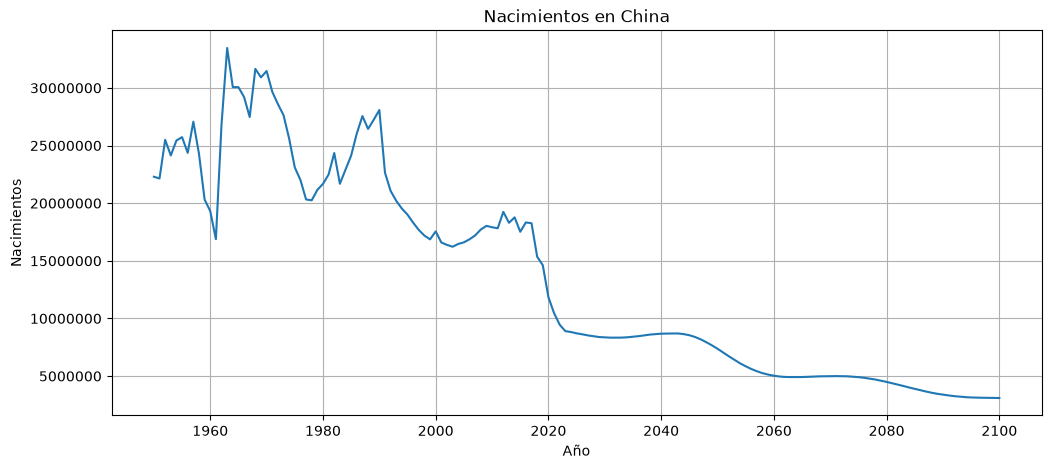

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_china["Year"],
    df_china["births"]
)

plt.title("Nacimientos en China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

## 3. Separar datos históricos y proyectados

Se usa el mismo punto de corte del notebook original: el año **2023**.

In [10]:
df_historico = df_china[
    df_china["Year"] <= 2023
]

df_proyectado = df_china[
    df_china["Year"] > 2023
]

print("Histórico  ->", df_historico.shape, "| años:", df_historico["Year"].min(), "a", df_historico["Year"].max())
print("Proyectado ->", df_proyectado.shape, "| años:", df_proyectado["Year"].min(), "a", df_proyectado["Year"].max())

Histórico  -> (74, 9) | años: 1950 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


In [11]:
df_historico[["Year", "births", "deaths"]].isna().sum()

Year      0
births    0
deaths    0
dtype: int64

## 4. Preparar las variables

* **X:** el año
* **y:** los nacimientos

In [12]:
X = df_historico[["Year"]]
y_nacimientos = df_historico["births"]

print("X.shape:", X.shape)
print("y.shape:", y_nacimientos.shape)
X.head()

X.shape: (74, 1)
y.shape: (74,)


,Year
7097,1950
7098,1951
7099,1952
7100,1953
7101,1954


In [13]:
anios_futuros = np.arange(2024, 2101).reshape(-1, 1)

X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro.head()

,Year
0,2024
1,2025
2,2026
3,2027
4,2028


## 5. China — Regresión lineal

In [14]:
modelo_lineal = LinearRegression()

modelo_lineal.fit(X, y_nacimientos)

print("Pendiente (a):", modelo_lineal.coef_[0])
print("Intercepto (b):", modelo_lineal.intercept_)

Pendiente (a): -187208.31004813028
Intercepto (b): 393489519.9376378


In [15]:
predicciones_lineal = modelo_lineal.predict(X)

predicciones_lineal_futuras = modelo_lineal.predict(X_futuro)

print(predicciones_lineal_futuras[:10])

[14579900.40022212 14392692.09017396 14205483.78012586 14018275.47007769
 13831067.16002959 13643858.84998149 13456650.53993332 13269442.22988522
 13082233.91983706 12895025.60978895]


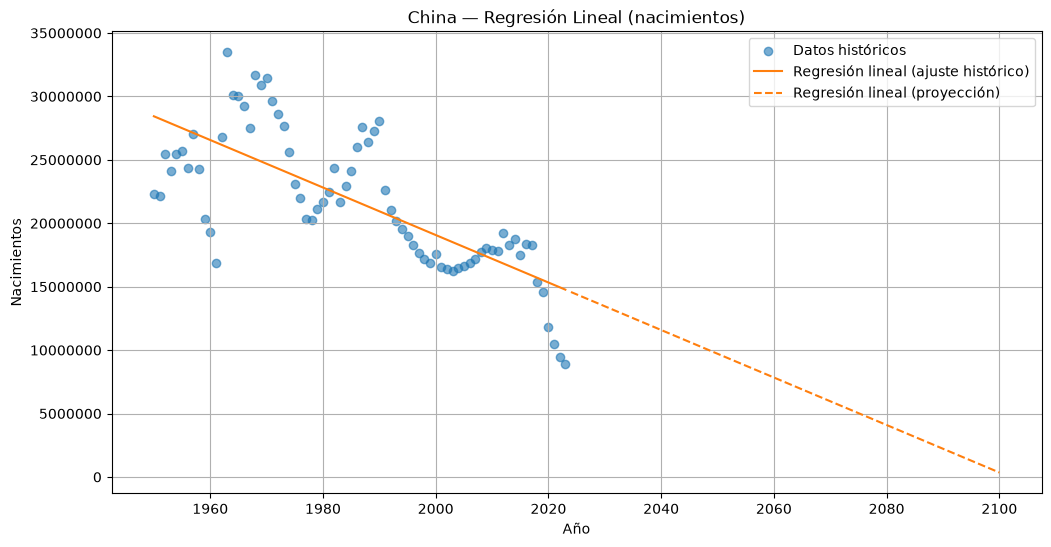

In [16]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_lineal,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("China — Regresión Lineal (nacimientos)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 6. China — Regresión polinomial

Polinomio de grado 2, igual que en el notebook original.

In [17]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X)

X_poly[:5]

array([[1.950000e+03, 3.802500e+06],
       [1.951000e+03, 3.806401e+06],
       [1.952000e+03, 3.810304e+06],
       [1.953000e+03, 3.814209e+06],
       [1.954000e+03, 3.818116e+06]])

In [18]:
modelo_polinomial = LinearRegression()

modelo_polinomial.fit(
    X_poly,
    y_nacimientos
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[15379568.11, -3918.14]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.507e+10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[730030.32, 0.88]"


In [19]:
predicciones_polinomiales = modelo_polinomial.predict(X_poly)

anios_futuros_poly = poly.transform(X_futuro)

predicciones_polinomiales_futuras = modelo_polinomial.predict(anios_futuros_poly)

print(predicciones_polinomiales_futuras[:10])

[10857665.91793251 10372678.84930038  9879855.49754906  9379195.86267662
  8870699.94468307  8354367.74357033  7830199.25933647  7298194.49198151
  6758353.44150543  6210676.10790634]


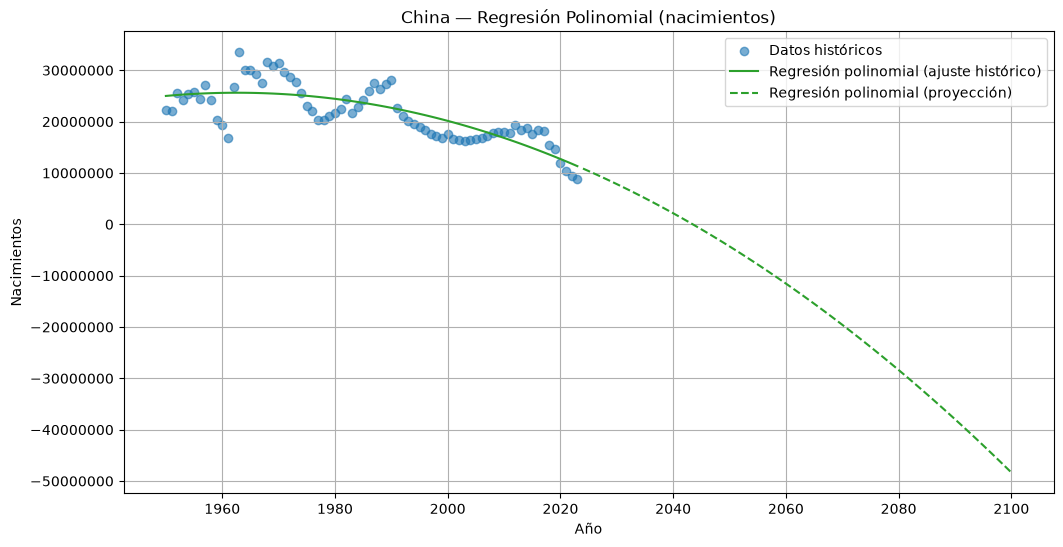

In [20]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_polinomiales,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("China — Regresión Polinomial (nacimientos)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 7. China — Random Forest Regressor

In [21]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(
    X,
    y_nacimientos
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [22]:
predicciones_rf = modelo_rf.predict(X)

predicciones_rf_futuras = modelo_rf.predict(X_futuro)

print(predicciones_rf_futuras[:10])

[9489420.42 9489420.42 9489420.42 9489420.42 9489420.42 9489420.42
 9489420.42 9489420.42 9489420.42 9489420.42]


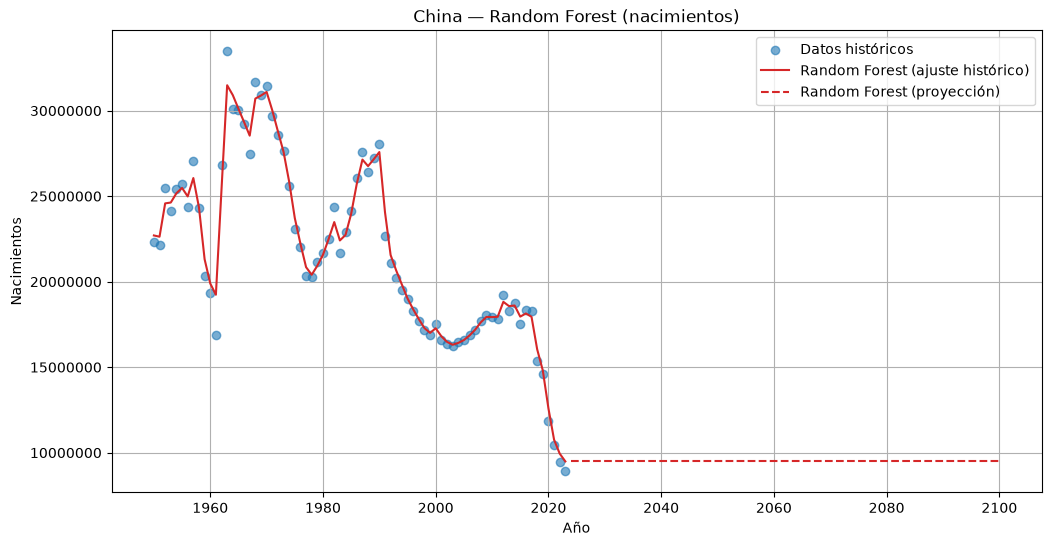

In [23]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_rf,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("China — Random Forest (nacimientos)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 8. China — Comparación de los tres modelos

Primero los valores reales contra el ajuste de cada modelo (años históricos) y después
las tres proyecciones juntas.

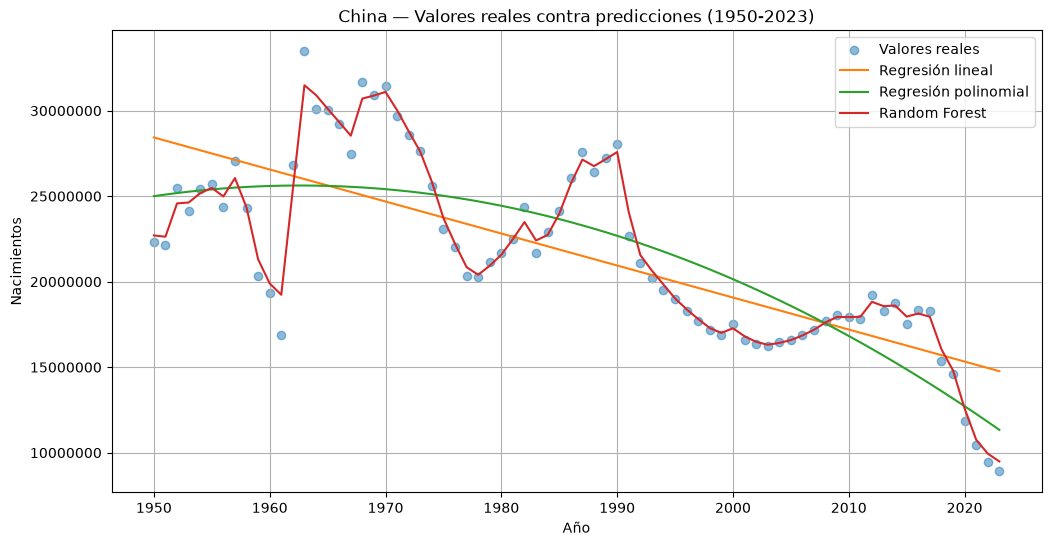

In [24]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Valores reales",
    alpha=0.5
)

plt.plot(df_historico["Year"], predicciones_lineal, color="tab:orange", label="Regresión lineal")
plt.plot(df_historico["Year"], predicciones_polinomiales, color="tab:green", label="Regresión polinomial")
plt.plot(df_historico["Year"], predicciones_rf, color="tab:red", label="Random Forest")

plt.title("China — Valores reales contra predicciones (1950-2023)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

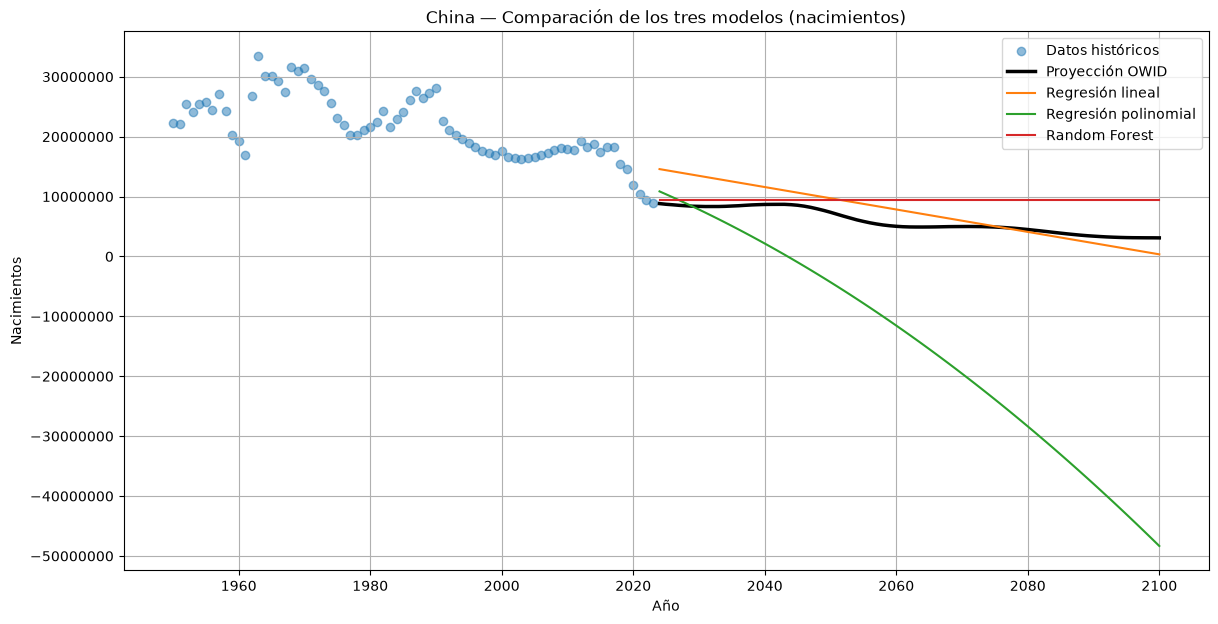

In [25]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    df_proyectado["Year"],
    df_proyectado["births"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(anios_futuros.flatten(), predicciones_lineal_futuras, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), predicciones_polinomiales_futuras, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), predicciones_rf_futuras, color="tab:red", label="Random Forest")

plt.title("China — Comparación de los tres modelos (nacimientos)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

In [26]:
anios_tabla = [2030, 2050, 2075, 2100]
indice = anios_futuros.flatten()


def construir_tabla(owid, lineal, polinomial, rf):
    tabla = pd.DataFrame(
        {
            "OWID": owid.set_index("Year").reindex(indice).to_numpy().ravel(),
            "Regresión lineal": lineal,
            "Regresión polinomial": polinomial,
            "Random Forest": rf,
        },
        index=indice
    )
    tabla.index.name = "Año"
    return tabla.loc[anios_tabla]


print("CHINA - NACIMIENTOS")
tabla_china = construir_tabla(
    df_proyectado[["Year", "births"]],
    predicciones_lineal_futuras,
    predicciones_polinomiales_futuras,
    predicciones_rf_futuras
)
display(tabla_china.style.format("{:,.0f}"))

CHINA - NACIMIENTOS


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"8,359,513","13,456,651","7,830,199","9,489,420"
2050,"7,371,348","9,712,484","-4,298,790","9,489,420"
2075,"4,909,046","5,032,277","-23,867,936","9,489,420"
2100,"3,099,844","352,069","-48,334,758","9,489,420"


---

# EJERCICIO 2 — MÉXICO DESDE EL AÑO 2000

## 1. Extraer México

In [27]:
pais = "Mexico"

df_mexico = df[df["Entity"] == pais]

print("Rango de años:", df_mexico["Year"].min(), "-", df_mexico["Year"].max())
df_mexico.head()

Rango de años: 1950 - 2100


,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22801,Mexico,MEX,1950,596771.0,NaN,1358501.0,NaN,1358501.0,596771.0
22802,Mexico,MEX,1951,588791.0,NaN,1392106.0,NaN,1392106.0,588791.0
22803,Mexico,MEX,1952,582415.0,NaN,1423352.0,NaN,1423352.0,582415.0
22804,Mexico,MEX,1953,565876.0,NaN,1454762.0,NaN,1454762.0,565876.0
22805,Mexico,MEX,1954,552321.0,NaN,1488719.0,NaN,1488719.0,552321.0


## 2. Filtrar los datos desde el año 2000

A diferencia del notebook original, aquí el entrenamiento solo usa los años **2000 a 2023**.

In [28]:
df_mexico_2000 = df_mexico[
    df_mexico["Year"] >= 2000
]

print("Filas desde el año 2000:", df_mexico_2000.shape[0])
print("Rango de años:", df_mexico_2000["Year"].min(), "-", df_mexico_2000["Year"].max())

Filas desde el año 2000: 101
Rango de años: 2000 - 2100


## 3. Mostrar los datos resultantes: nacimientos y defunciones

In [29]:
df_mexico_2000[["Entity", "Year", "births", "deaths"]].head(15)

,Entity,Year,births,deaths
22851,Mexico,2000,2385977.0,540567.0
22852,Mexico,2001,2380261.0,543803.0
22853,Mexico,2002,2374140.0,553391.0
22854,Mexico,2003,2351177.0,563140.0
22855,Mexico,2004,2335226.0,575925.0
22856,Mexico,2005,2318498.0,585859.0
22857,Mexico,2006,2303997.0,597892.0
22858,Mexico,2007,2296268.0,611318.0
22859,Mexico,2008,2297950.0,627177.0
22860,Mexico,2009,2303532.0,642292.0


In [30]:
df_historico_mx = df_mexico_2000[
    df_mexico_2000["Year"] <= 2023
]

df_proyectado_mx = df_mexico_2000[
    df_mexico_2000["Year"] > 2023
]

print("Histórico  ->", df_historico_mx.shape, "| años:", df_historico_mx["Year"].min(), "a", df_historico_mx["Year"].max())
print("Proyectado ->", df_proyectado_mx.shape, "| años:", df_proyectado_mx["Year"].min(), "a", df_proyectado_mx["Year"].max())

df_historico_mx[["Year", "births", "deaths"]].isna().sum()

Histórico  -> (24, 9) | años: 2000 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


Year      0
births    0
deaths    0
dtype: int64

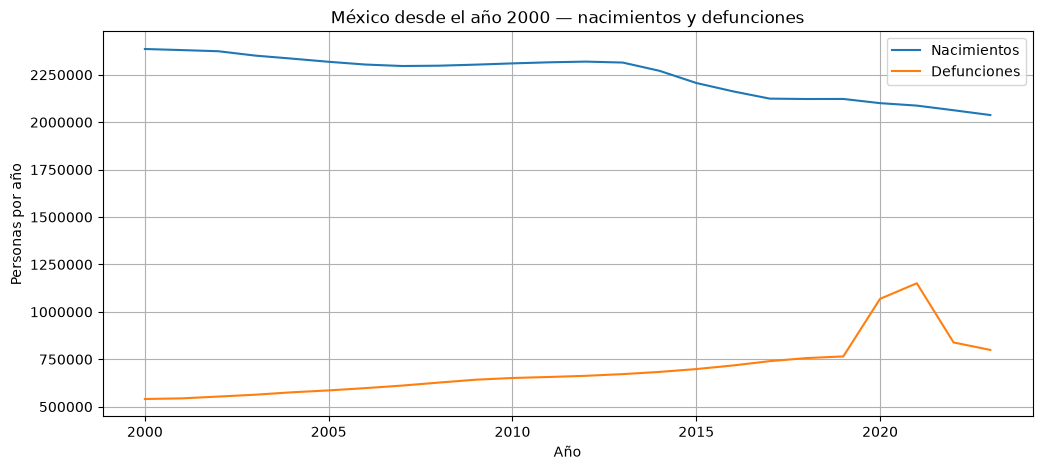

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(df_historico_mx["Year"], df_historico_mx["births"], label="Nacimientos")
plt.plot(df_historico_mx["Year"], df_historico_mx["deaths"], label="Defunciones")

plt.title("México desde el año 2000 — nacimientos y defunciones")
plt.xlabel("Año")
plt.ylabel("Personas por año")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 4. Preparar las variables

`X` vuelve a ser el año; ahora se trabajan dos variables objetivo: nacimientos y defunciones.

In [32]:
X_mx = df_historico_mx[["Year"]]

y_nacimientos_mx = df_historico_mx["births"]
y_defunciones_mx = df_historico_mx["deaths"]

print("X_mx.shape:", X_mx.shape)
print("y_nacimientos_mx.shape:", y_nacimientos_mx.shape)
print("y_defunciones_mx.shape:", y_defunciones_mx.shape)

X_mx.shape: (24, 1)
y_nacimientos_mx.shape: (24,)
y_defunciones_mx.shape: (24,)


In [33]:
X_futuro_mx = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro_mx.head()

,Year
0,2024
1,2025
2,2026
3,2027
4,2028


---

## 5. México — NACIMIENTOS

### 5.1 Regresión lineal

In [34]:
modelo_lineal_nac = LinearRegression()

modelo_lineal_nac.fit(X_mx, y_nacimientos_mx)

print("Pendiente (a):", modelo_lineal_nac.coef_[0])
print("Intercepto (b):", modelo_lineal_nac.intercept_)

predicciones_lineal_nac = modelo_lineal_nac.predict(X_mx)
predicciones_lineal_nac_futuras = modelo_lineal_nac.predict(X_futuro_mx)

Pendiente (a): -14819.746956521738
Intercepto (b): 32055962.503043476


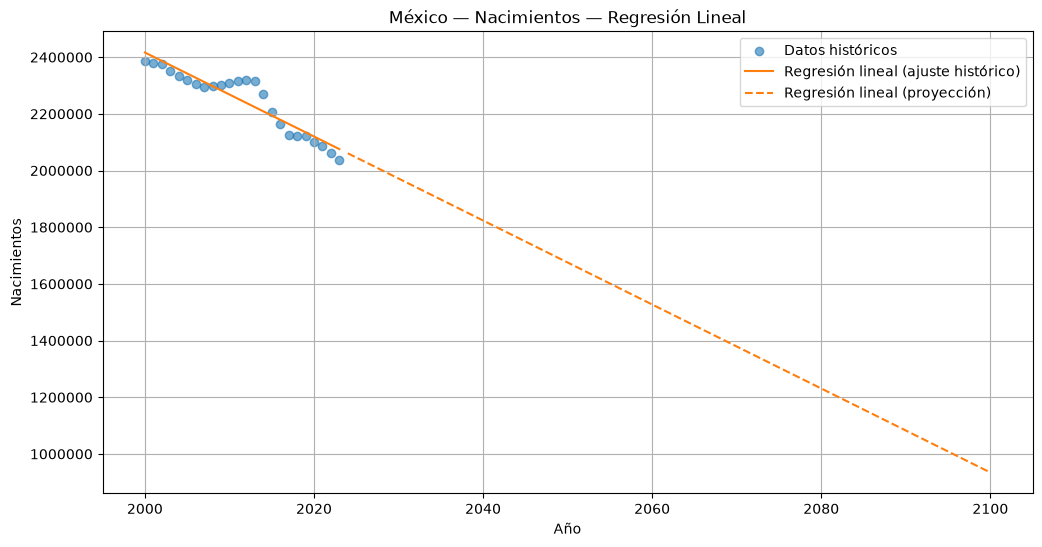

In [35]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico_mx["Year"],
    df_historico_mx["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico_mx["Year"],
    predicciones_lineal_nac,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_nac_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("México — Nacimientos — Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### 5.2 Regresión polinomial

In [36]:
poly_mx = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly_mx = poly_mx.fit_transform(X_mx)
anios_futuros_poly_mx = poly_mx.transform(X_futuro_mx)

modelo_polinomial_nac = LinearRegression()

modelo_polinomial_nac.fit(X_poly_mx, y_nacimientos_mx)

predicciones_polinomiales_nac = modelo_polinomial_nac.predict(X_poly_mx)
predicciones_polinomiales_nac_futuras = modelo_polinomial_nac.predict(anios_futuros_poly_mx)

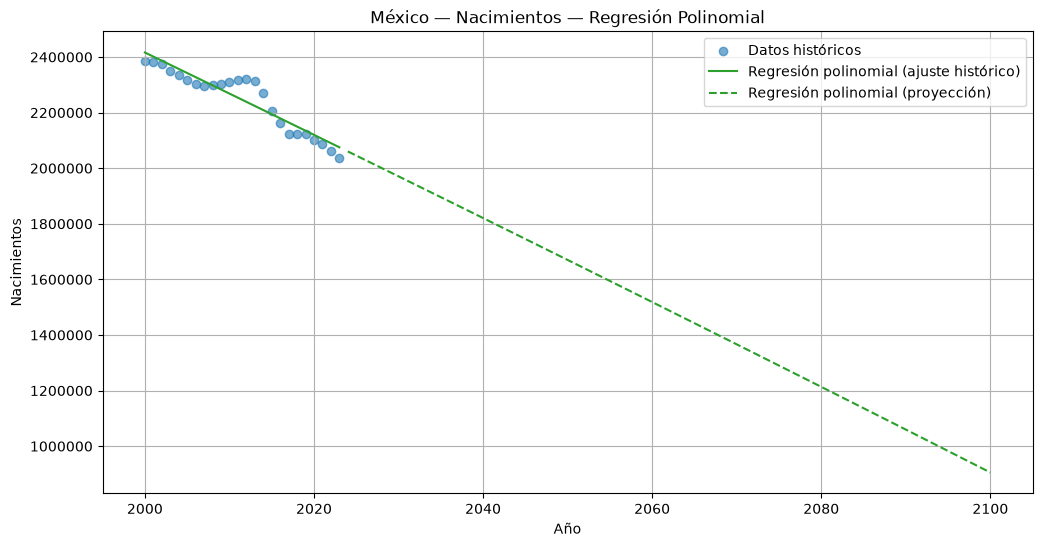

In [37]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico_mx["Year"],
    df_historico_mx["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico_mx["Year"],
    predicciones_polinomiales_nac,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_nac_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("México — Nacimientos — Regresión Polinomial")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### 5.3 Random Forest Regressor

In [38]:
modelo_rf_nac = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_nac.fit(X_mx, y_nacimientos_mx)

predicciones_rf_nac = modelo_rf_nac.predict(X_mx)
predicciones_rf_nac_futuras = modelo_rf_nac.predict(X_futuro_mx)

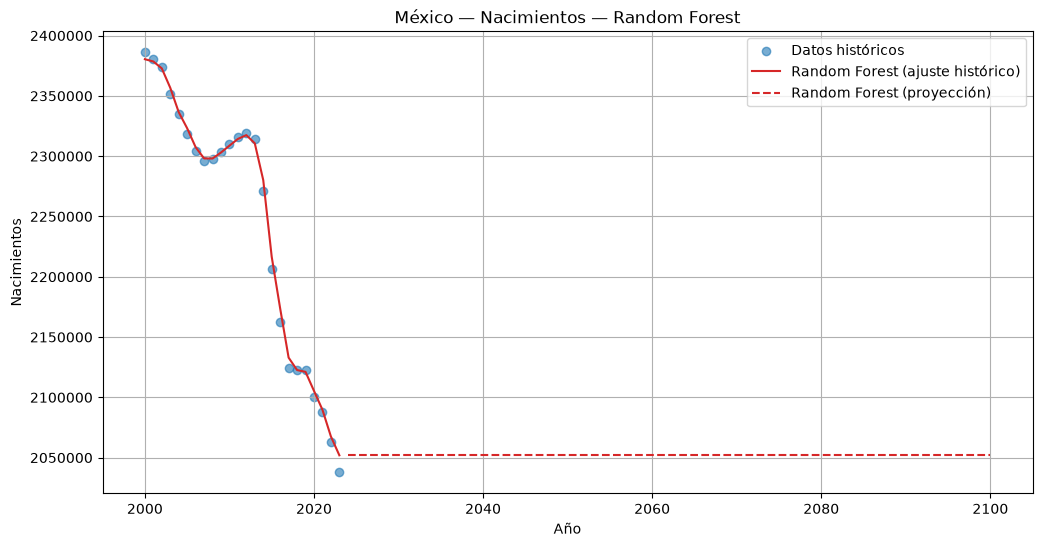

In [39]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico_mx["Year"],
    df_historico_mx["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico_mx["Year"],
    predicciones_rf_nac,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_nac_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("México — Nacimientos — Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### 5.4 Nacimientos: valores reales contra predicciones

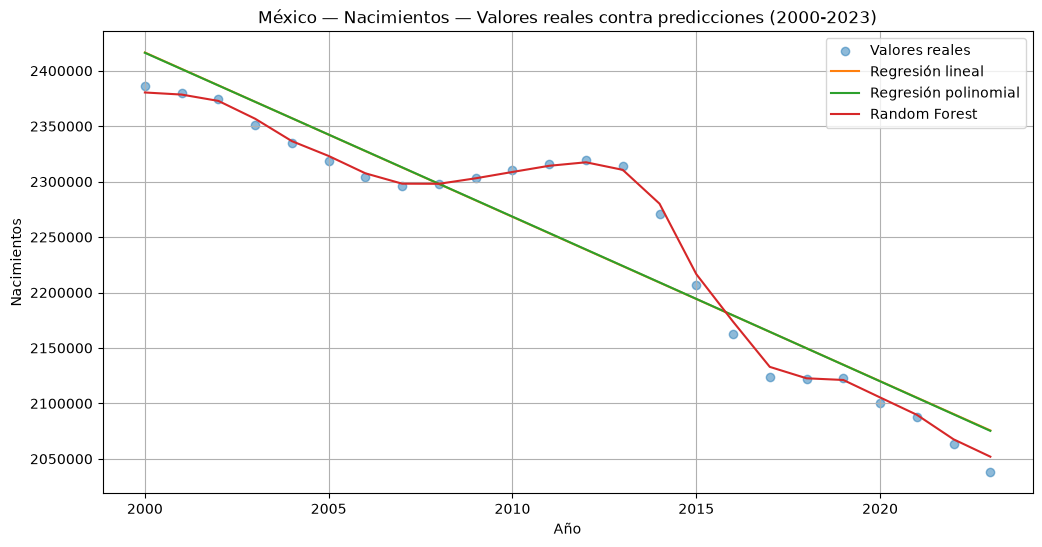

In [40]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico_mx["Year"],
    df_historico_mx["births"],
    label="Valores reales",
    alpha=0.5
)

plt.plot(df_historico_mx["Year"], predicciones_lineal_nac, color="tab:orange", label="Regresión lineal")
plt.plot(df_historico_mx["Year"], predicciones_polinomiales_nac, color="tab:green", label="Regresión polinomial")
plt.plot(df_historico_mx["Year"], predicciones_rf_nac, color="tab:red", label="Random Forest")

plt.title("México — Nacimientos — Valores reales contra predicciones (2000-2023)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

---

## 6. México — DEFUNCIONES

Se repite exactamente el mismo proceso, cambiando la variable objetivo.

### 6.1 Regresión lineal

In [41]:
modelo_lineal_def = LinearRegression()

modelo_lineal_def.fit(X_mx, y_defunciones_mx)

print("Pendiente (a):", modelo_lineal_def.coef_[0])
print("Intercepto (b):", modelo_lineal_def.intercept_)

predicciones_lineal_def = modelo_lineal_def.predict(X_mx)
predicciones_lineal_def_futuras = modelo_lineal_def.predict(X_futuro_mx)

Pendiente (a): 17578.816521739132
Intercepto (b): -34663868.933478266


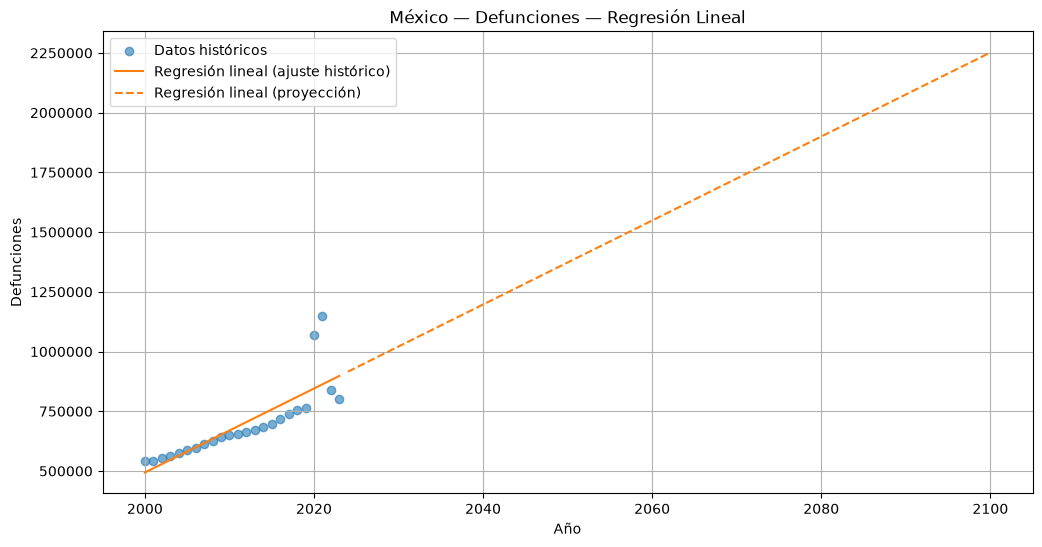

In [42]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico_mx["Year"],
    df_historico_mx["deaths"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico_mx["Year"],
    predicciones_lineal_def,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_def_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("México — Defunciones — Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### 6.2 Regresión polinomial

In [43]:
modelo_polinomial_def = LinearRegression()

modelo_polinomial_def.fit(X_poly_mx, y_defunciones_mx)

predicciones_polinomiales_def = modelo_polinomial_def.predict(X_poly_mx)
predicciones_polinomiales_def_futuras = modelo_polinomial_def.predict(anios_futuros_poly_mx)

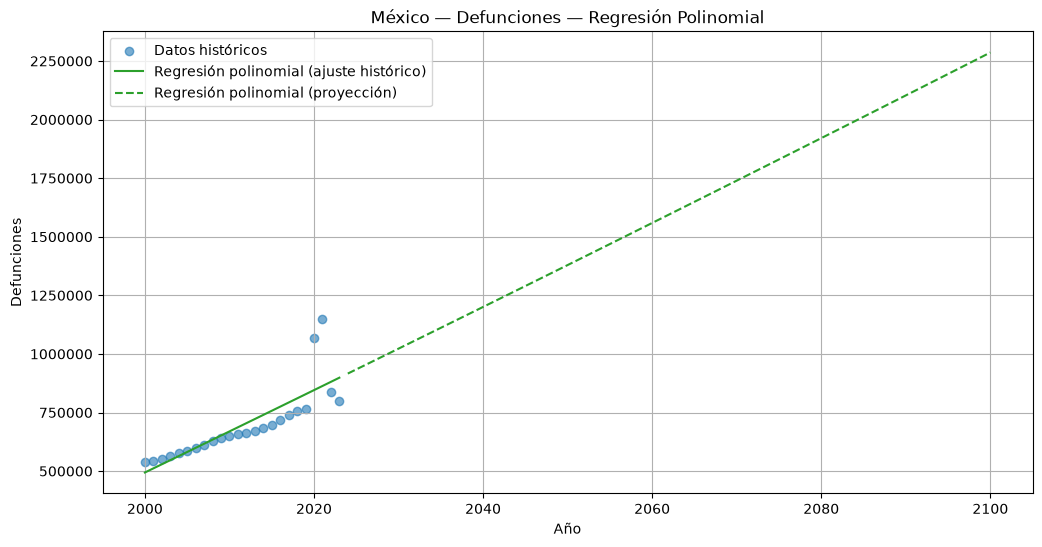

In [44]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico_mx["Year"],
    df_historico_mx["deaths"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico_mx["Year"],
    predicciones_polinomiales_def,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_def_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("México — Defunciones — Regresión Polinomial")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### 6.3 Random Forest Regressor

In [45]:
modelo_rf_def = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_def.fit(X_mx, y_defunciones_mx)

predicciones_rf_def = modelo_rf_def.predict(X_mx)
predicciones_rf_def_futuras = modelo_rf_def.predict(X_futuro_mx)

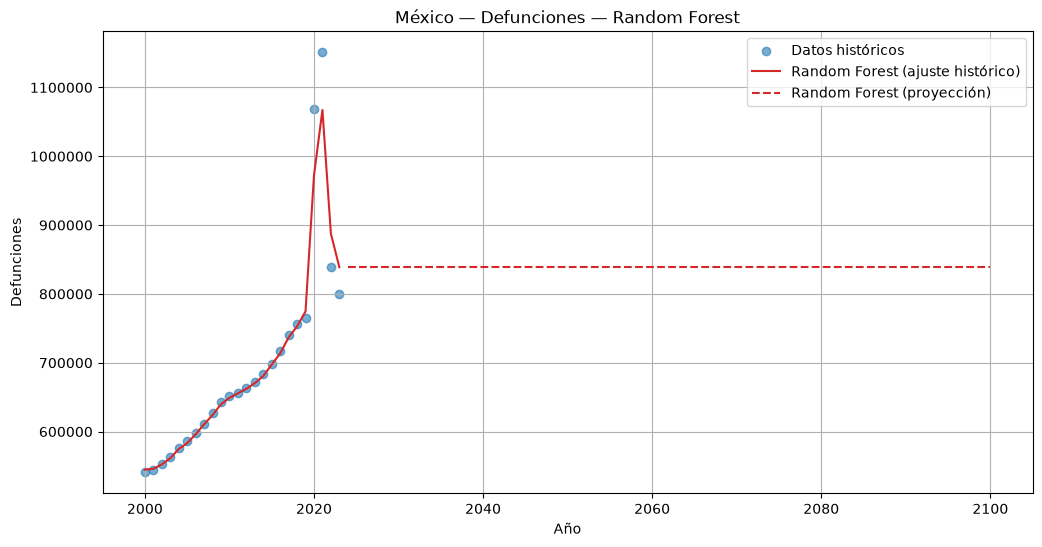

In [46]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico_mx["Year"],
    df_historico_mx["deaths"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico_mx["Year"],
    predicciones_rf_def,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_def_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("México — Defunciones — Random Forest")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### 6.4 Defunciones: valores reales contra predicciones

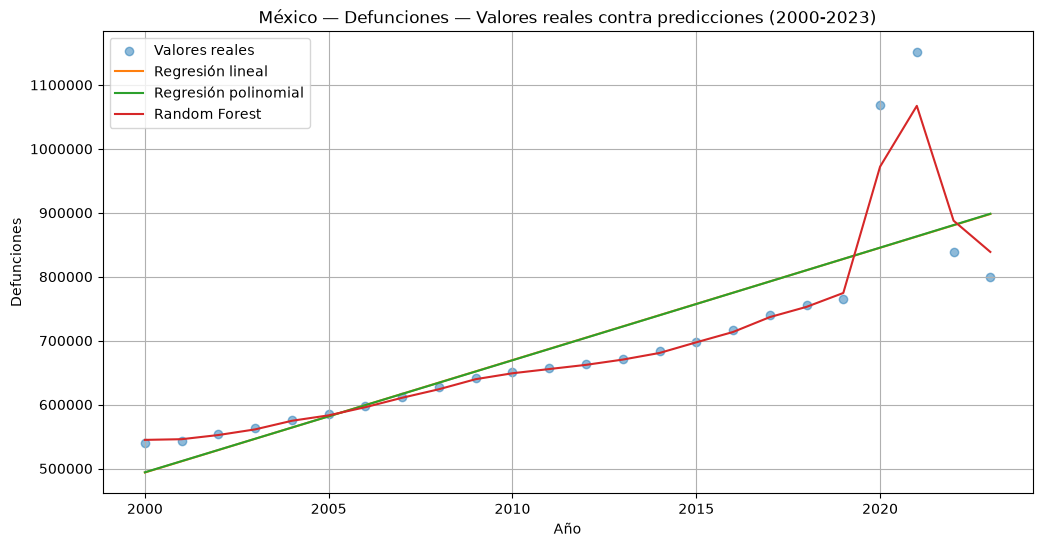

In [47]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico_mx["Year"],
    df_historico_mx["deaths"],
    label="Valores reales",
    alpha=0.5
)

plt.plot(df_historico_mx["Year"], predicciones_lineal_def, color="tab:orange", label="Regresión lineal")
plt.plot(df_historico_mx["Year"], predicciones_polinomiales_def, color="tab:green", label="Regresión polinomial")
plt.plot(df_historico_mx["Year"], predicciones_rf_def, color="tab:red", label="Random Forest")

plt.title("México — Defunciones — Valores reales contra predicciones (2000-2023)")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

---

## 7. México — Comparación de resultados

Las proyecciones de los tres modelos, separando claramente **nacimientos** y **defunciones**.

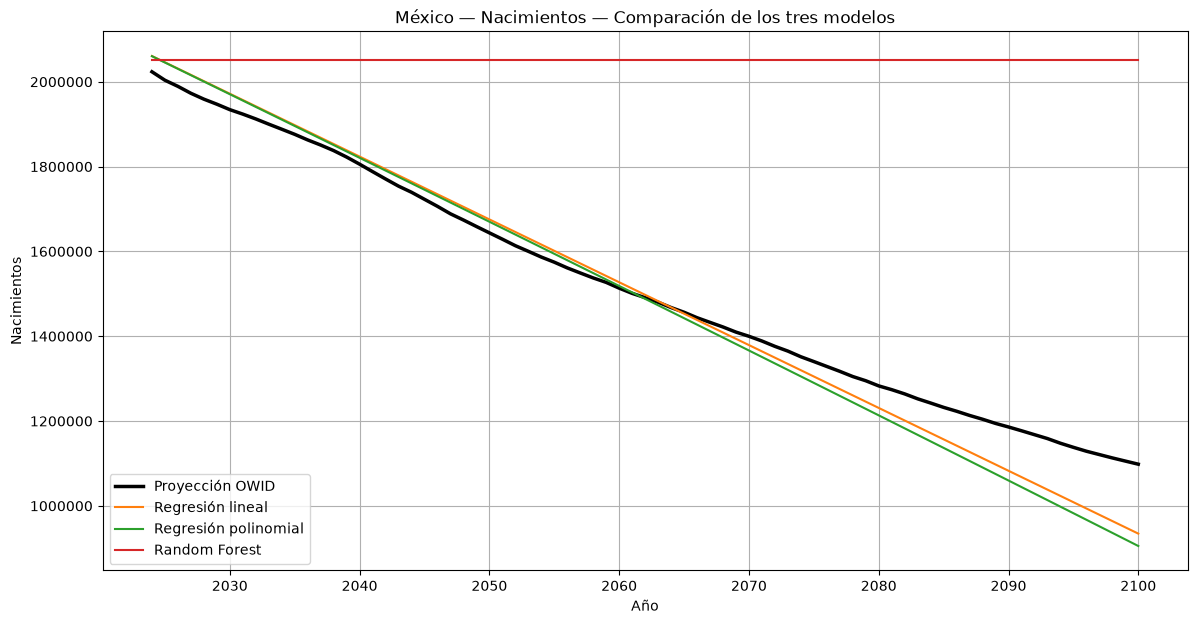

In [48]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado_mx["Year"],
    df_proyectado_mx["births"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(anios_futuros.flatten(), predicciones_lineal_nac_futuras, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), predicciones_polinomiales_nac_futuras, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), predicciones_rf_nac_futuras, color="tab:red", label="Random Forest")

plt.title("México — Nacimientos — Comparación de los tres modelos")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

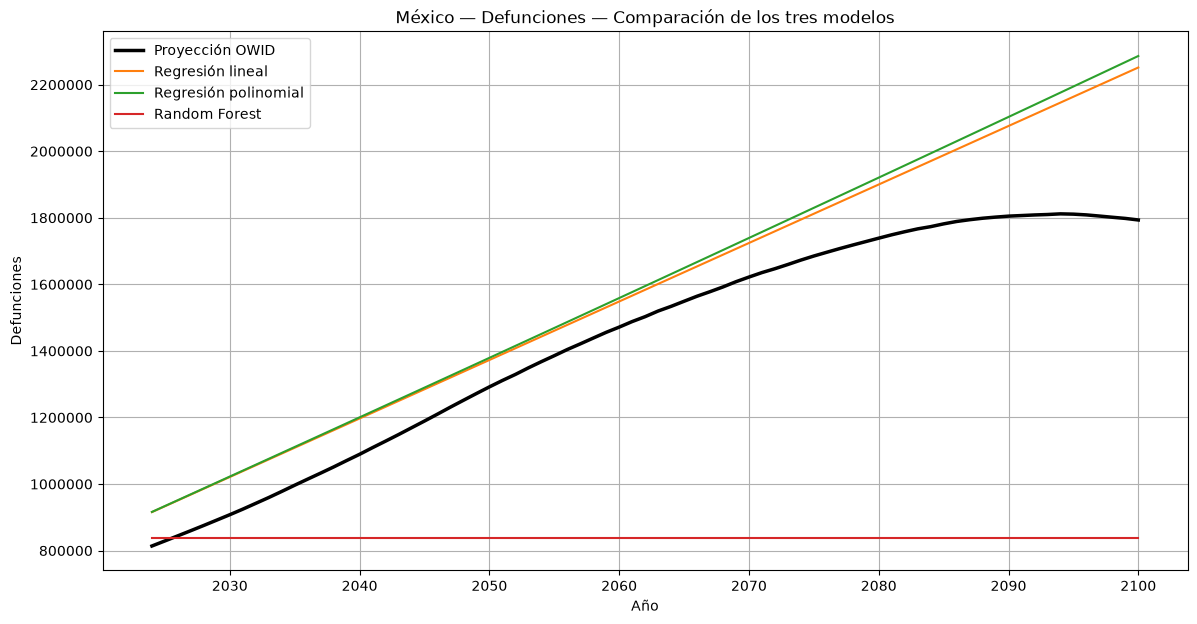

In [49]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado_mx["Year"],
    df_proyectado_mx["deaths"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(anios_futuros.flatten(), predicciones_lineal_def_futuras, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), predicciones_polinomiales_def_futuras, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), predicciones_rf_def_futuras, color="tab:red", label="Random Forest")

plt.title("México — Defunciones — Comparación de los tres modelos")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

In [50]:
print("MÉXICO (datos desde 2000) - NACIMIENTOS")
tabla_mx_nacimientos = construir_tabla(
    df_proyectado_mx[["Year", "births"]],
    predicciones_lineal_nac_futuras,
    predicciones_polinomiales_nac_futuras,
    predicciones_rf_nac_futuras
)
display(tabla_mx_nacimientos.style.format("{:,.0f}"))

print("MÉXICO (datos desde 2000) - DEFUNCIONES")
tabla_mx_defunciones = construir_tabla(
    df_proyectado_mx[["Year", "deaths"]],
    predicciones_lineal_def_futuras,
    predicciones_polinomiales_def_futuras,
    predicciones_rf_def_futuras
)
display(tabla_mx_defunciones.style.format("{:,.0f}"))

MÉXICO (datos desde 2000) - NACIMIENTOS


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"1,934,285","1,971,876","1,970,689","2,051,955"
2050,"1,643,767","1,675,481","1,669,982","2,051,955"
2075,"1,340,246","1,304,988","1,289,953","2,051,955"
2100,"1,098,210","934,494","905,317","2,051,955"


MÉXICO (datos desde 2000) - DEFUNCIONES


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"907,843","1,021,129","1,022,528","838,793"
2050,"1,291,889","1,372,705","1,379,209","838,793"
2075,"1,685,181","1,812,175","1,829,978","838,793"
2100,"1,793,462","2,251,646","2,286,211","838,793"


---

# PARTE 3. Datasets adicionales de Our World in Data

Además del dataset de nacimientos y defunciones, se cargan dos indicadores más,
con el mismo método (`pd.read_csv` directo desde OWID):

1. **Total healthcare spending as a share of GDP (2000 a 2023)** — gasto total en salud
   como porcentaje del PIB.
2. **GDP per capita** — PIB por persona.

## 1. Gasto en salud como porcentaje del PIB

In [51]:
df_health = pd.read_csv(
    "https://ourworldindata.org/grapher/total-healthcare-expenditure-gdp.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
)

df_health.head()

,entity,code,year,current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct
0,Afghanistan,AFG,2002,9.443391
1,Afghanistan,AFG,2003,8.941258
2,Afghanistan,AFG,2004,9.808474
3,Afghanistan,AFG,2005,9.948289
4,Afghanistan,AFG,2006,10.622766


In [52]:
print("Dimensiones (filas, columnas):", df_health.shape)
print("Rango de años:", df_health["year"].min(), "-", df_health["year"].max())
print()
print("Columnas:")
for columna in df_health.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (4756, 4)
Rango de años: 2000 - 2023

Columnas:
  - entity
  - code
  - year
  - current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct


In [53]:
df_health = df_health.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct": "health_gdp_pct",
})

df_health.head()

,Entity,Code,Year,health_gdp_pct
0,Afghanistan,AFG,2002,9.443391
1,Afghanistan,AFG,2003,8.941258
2,Afghanistan,AFG,2004,9.808474
3,Afghanistan,AFG,2005,9.948289
4,Afghanistan,AFG,2006,10.622766


## 2. PIB per cápita

In [54]:
df_gdp = pd.read_csv(
    "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
)

df_gdp.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [55]:
print("Dimensiones (filas, columnas):", df_gdp.shape)
print("Rango de años:", df_gdp["year"].min(), "-", df_gdp["year"].max())
print()
print("Columnas:")
for columna in df_gdp.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (7445, 5)
Rango de años: 1990 - 2025

Columnas:
  - entity
  - code
  - year
  - ny_gdp_pcap_pp_kd
  - owid_region


In [56]:
df_gdp = df_gdp.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "ny_gdp_pcap_pp_kd": "gdp_per_capita",
})

df_gdp.head()

,Entity,Code,Year,gdp_per_capita,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


## 3. Extraer China y México

Se filtran los dos países que se usaron en los ejercicios, desde el año 2000.

In [57]:
paises = ["China", "Mexico"]

df_health_paises = df_health[
    (df_health["Entity"].isin(paises)) &
    (df_health["Year"] >= 2000)
]

df_gdp_paises = df_gdp[
    (df_gdp["Entity"].isin(paises)) &
    (df_gdp["Year"] >= 2000)
]

print("Gasto en salud ->", df_health_paises.shape)
print("PIB per cápita ->", df_gdp_paises.shape)

df_health_paises.head(10)

Gasto en salud -> (48, 4)
PIB per cápita -> (52, 5)


,Entity,Code,Year,health_gdp_pct
886,China,CHN,2000,4.453586
887,China,CHN,2001,4.197520
888,China,CHN,2002,4.321562
889,China,CHN,2003,4.354605
890,China,CHN,2004,4.229491
891,China,CHN,2005,4.112308
892,China,CHN,2006,3.886550
893,China,CHN,2007,3.617377
894,China,CHN,2008,3.836278
895,China,CHN,2009,4.276320


In [58]:
df_gdp_paises.head(10)

,Entity,Code,Year,gdp_per_capita,owid_region
1347,China,CHN,2000,4065.8672,Asia
1348,China,CHN,2001,4372.4355,Asia
1349,China,CHN,2002,4744.3820,Asia
1350,China,CHN,2003,5191.7812,Asia
1351,China,CHN,2004,5684.3880,Asia
1352,China,CHN,2005,6298.2993,Asia
1353,China,CHN,2006,7057.1113,Asia
1354,China,CHN,2007,8013.7837,Asia
1355,China,CHN,2008,8743.7020,Asia
1356,China,CHN,2009,9518.6820,Asia


## 4. Gráficas de los dos indicadores

Mismo estilo de gráficas que se usó en los ejercicios anteriores.

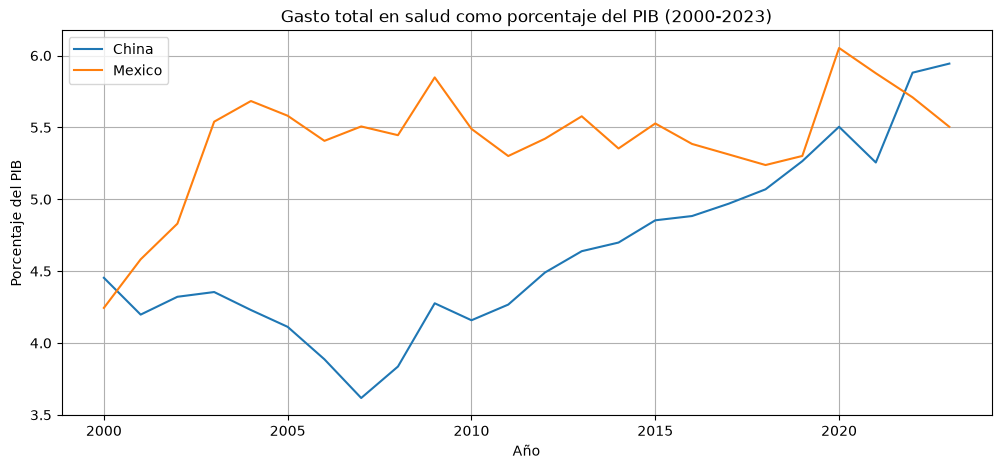

In [59]:
plt.figure(figsize=(12, 5))

for pais in paises:
    datos = df_health_paises[df_health_paises["Entity"] == pais]
    plt.plot(datos["Year"], datos["health_gdp_pct"], label=pais)

plt.title("Gasto total en salud como porcentaje del PIB (2000-2023)")
plt.xlabel("Año")
plt.ylabel("Porcentaje del PIB")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

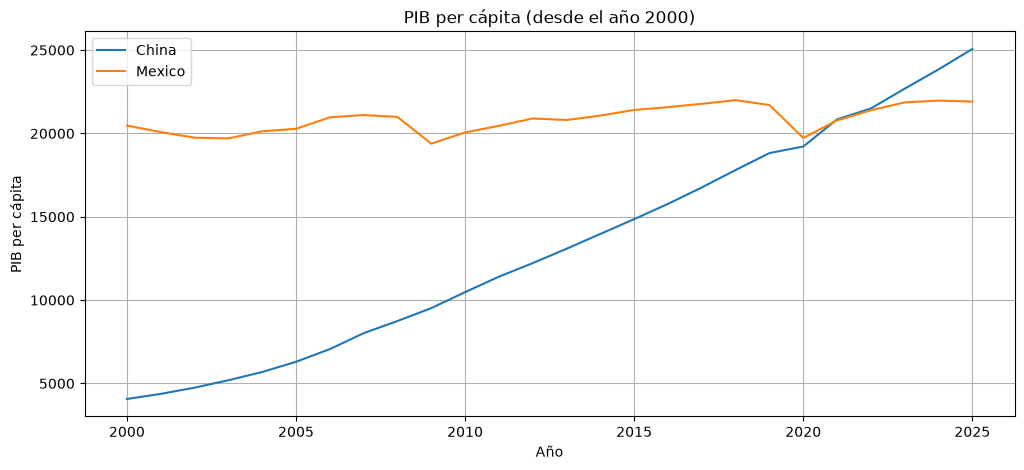

In [60]:
plt.figure(figsize=(12, 5))

for pais in paises:
    datos = df_gdp_paises[df_gdp_paises["Entity"] == pais]
    plt.plot(datos["Year"], datos["gdp_per_capita"], label=pais)

plt.title("PIB per cápita (desde el año 2000)")
plt.xlabel("Año")
plt.ylabel("PIB per cápita")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

---

# Observaciones finales

* **China:** los tres modelos parten de los mismos datos (1950-2023) y aun así dibujan
  proyecciones distintas: una recta, una curva y una línea plana.
* **México desde 2000:** al usar solo 24 años de entrenamiento, la recta y la curva quedan
  más pegadas a la tendencia reciente que cuando se usaba toda la serie desde 1950.
* En los dos ejercicios el Random Forest se queda constante después de 2023, porque los
  modelos de árboles no pueden extrapolar fuera del rango de años con el que se entrenaron.
* Igual que en el notebook original, en este trabajo solo se construyen y comparan los
  modelos; la evaluación formal con métricas corresponde a la siguiente práctica.